In [1]:
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import mplhep as hep
import hist

plt.style.use(hep.style.CMS)

In [2]:
# Here, we are plotting 8 JSON data files
# Each JSON files contains 120 intervals, corresponding to a 120 second iPerf3 test
num_intervals = 120
num_network_tests = 8

# Create arrays to be filled with data
summed_bps_list = np.zeros(num_intervals)
full_arr = np.array([])

# Loop through all the JSON files, which contain the test results data
for file in glob.glob("*.json"):
    with open(file) as f:
        data = json.load(f)
        bps_list = np.array([])
        for interval in data["intervals"]:
            # We divide by 1e9 to go from bits per second to gigabits per second
            bps = interval["sum"]["bits_per_second"]/1e9
            bps_list = np.append(bps_list, bps)
        summed_bps_list = summed_bps_list + bps_list
        full_arr = np.concatenate((full_arr, bps_list))

full_arr_reshaped = full_arr.reshape((num_network_tests,num_intervals))

In [3]:
x = range(len(summed_bps_list))
a_val = 0.75
colors = mcolors.TABLEAU_COLORS

In [4]:
colors

{'tab:blue': '#1f77b4',
 'tab:orange': '#ff7f0e',
 'tab:green': '#2ca02c',
 'tab:red': '#d62728',
 'tab:purple': '#9467bd',
 'tab:brown': '#8c564b',
 'tab:pink': '#e377c2',
 'tab:gray': '#7f7f7f',
 'tab:olive': '#bcbd22',
 'tab:cyan': '#17becf'}

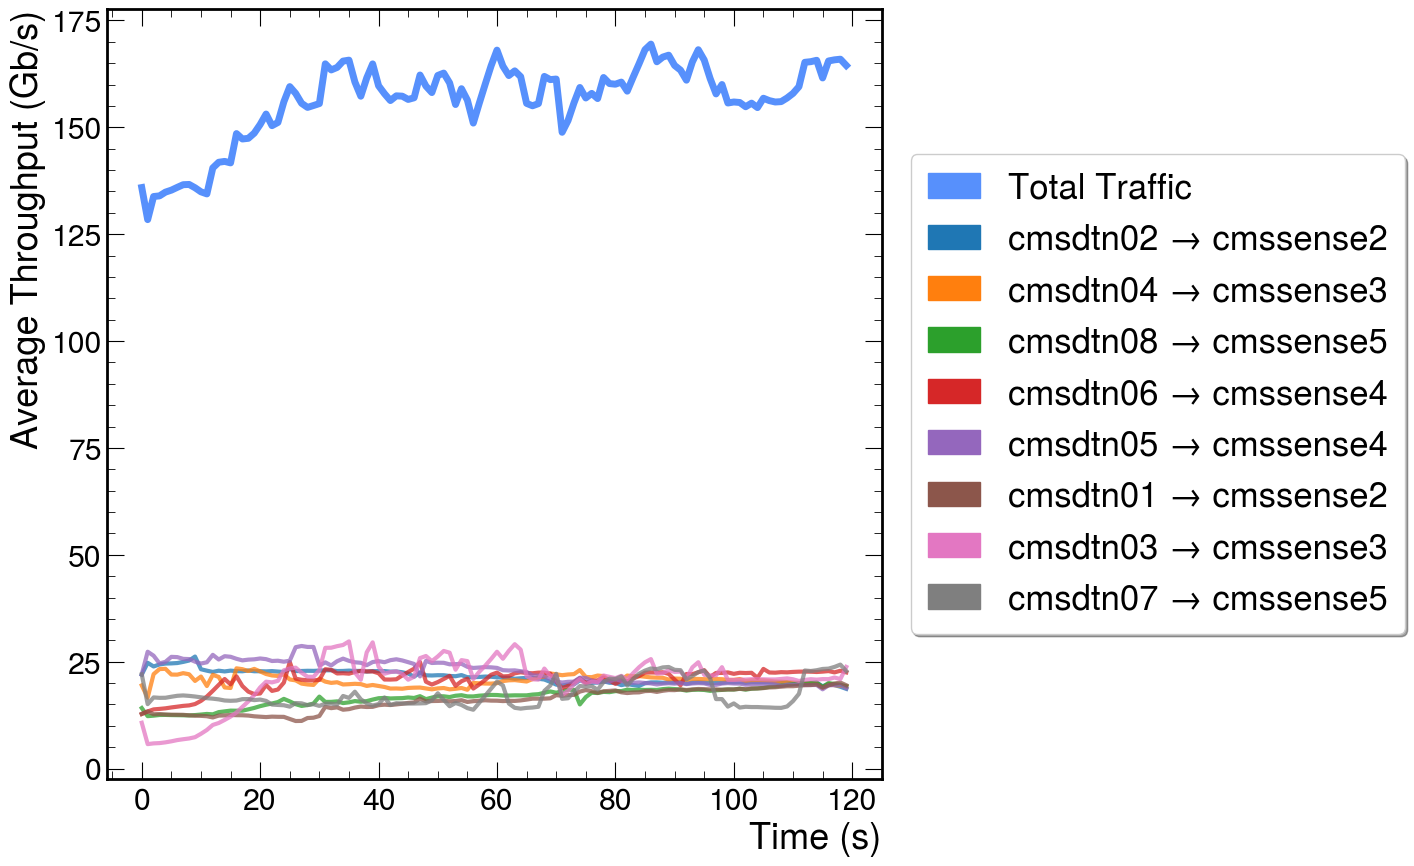

In [5]:
fig = plt.figure()
ax = plt.subplot(111)
plt.xlabel("Time (s)")
plt.ylabel("Average Throughput (Gb/s)")

# Plot summed traffic data
# Create patch with the default Matplotlib color #5790fc for the legend
ax.plot(x, summed_bps_list, lw=5)
patch0 = mpatches.Patch(color='#5790fc', label=f"Total Traffic")

# Loop through the 8 datasets to be plotted, assinging them a color from mcolors.TABLEAU_COLORS 
# We could use the default Matplotlib colors, but I personally like these ones!
for i, (k,v) in enumerate(mcolors.TABLEAU_COLORS.items()):
    if i >= 8:
        break
    ax.plot(x, full_arr_reshaped[i], lw=3, alpha=a_val, color=v)

# Make the color patches for the legend
patch1 = mpatches.Patch(color=colors['tab:blue'], label=f"cmsdtn02 → cmssense2")
patch2 = mpatches.Patch(color=colors['tab:orange'], label=f"cmsdtn04 → cmssense3")
patch3 = mpatches.Patch(color=colors['tab:green'], label=f"cmsdtn08 → cmssense5")
patch4 = mpatches.Patch(color=colors['tab:red'], label=f"cmsdtn06 → cmssense4")
patch5 = mpatches.Patch(color=colors['tab:purple'], label=f"cmsdtn05 → cmssense4")
patch6 = mpatches.Patch(color=colors['tab:brown'], label=f"cmsdtn01 → cmssense2")
patch7 = mpatches.Patch(color=colors['tab:pink'], label=f"cmsdtn03 → cmssense3")
patch8 = mpatches.Patch(color=colors['tab:gray'], label=f"cmsdtn07 → cmssense5")

# Create the legend and save the figure
ax.legend(bbox_to_anchor=(1.015, 0.5), loc='center left', shadow=True, ncol=1, handles=[patch0,
        patch1, patch2, patch3, patch4, patch5, patch6, patch7, patch8], frameon=True, fontsize=25)
plt.savefig("dtn_to_sense.pdf", dpi=600, bbox_inches='tight')